In [55]:
from pathlib import Path
import xarray
import matplotlib.pyplot as plt


In [9]:
p_ref = Path("../gdsps-hindcast/era5-grid/netcdf/SSH_y1993.nc")
p_forecast = Path("/home/osw001/data/ppp7/surge_anemoi_project/anemoi-stormsurge/inference/smoke_forecast_1993-11-01_1h_10_06_tendays.nc")

In [40]:


ds_forecast = xarray.open_dataset(p_forecast)
ssh_forecast = ds_forecast[ssh_name]
t_sel = ds_forecast.time

ds_ref = xarray.open_dataset(p_ref)
ssh_name = "sossheig"
ssh_ref = ds_ref[ssh_name].sel(time_counter=t_sel)


ssh_forecast_2d = ssh_ref.copy(data=ssh_forecast.values.reshape((ssh_forecast.shape[0],) + ssh_ref.shape[1:]))



/dev/shm/pbs.212479975.ppp7pbs-01-ib/ipykernel_582330/3091809384.py:1: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_forecast = xarray.open_dataset(p_forecast)


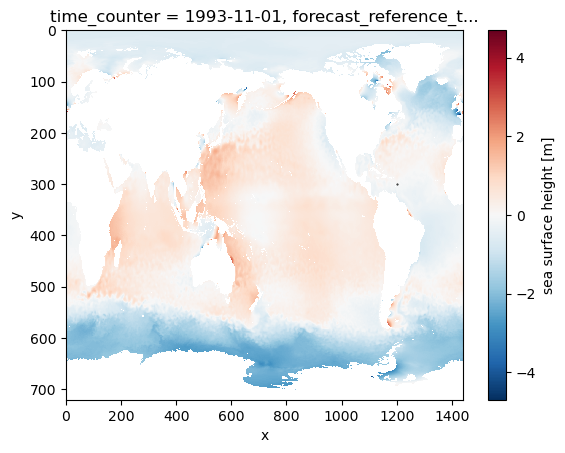

In [70]:
ax = plt.gca()
sel_point = (1200, 300)
ds_ref["sossheig"].sel(time_counter=t_sel[0]).plot(x="x", y="y", yincrease=False, ax=ax)
ax.scatter(sel_point[0], sel_point[1], c="k", s=0.2)

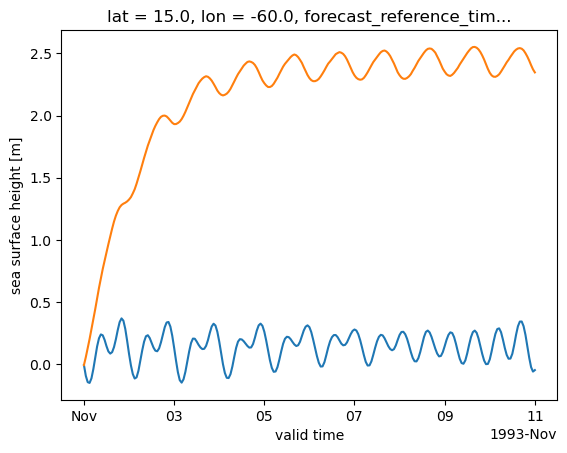

In [71]:
ax = plt.gca()

(ssh_ref).sel(x=sel_point[0], y=sel_point[1]).plot(x="time", ax=ax)
(ssh_forecast_2d).sel(x=sel_point[0], y=sel_point[1]).plot(x="time", ax=ax)


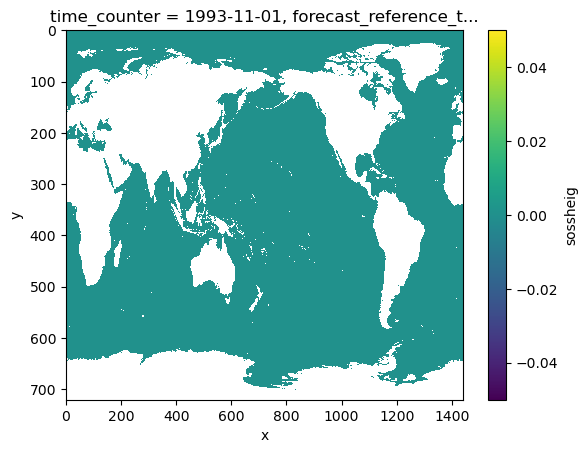

In [72]:
# lead time 0
(ssh_forecast_2d - ssh_ref).sel(time=t_sel[0]).plot(x="x", y="y", yincrease=False)

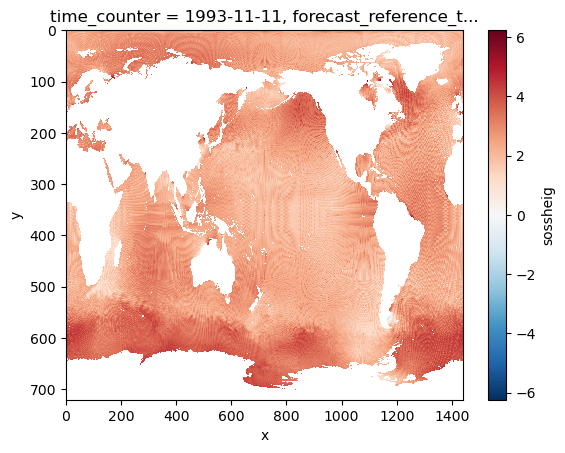

In [73]:
# 
(ssh_forecast_2d - ssh_ref).sel(time=t_sel[-1]).plot(x="x", y="y", yincrease=False)